In [3]:
from pathlib import Path
import pandas as pd

def find_upwards(start: Path, target_dir_name: str, max_levels: int = 10) -> Path:
    """
    Starting from `start`, go up parent directories until finding a folder named `target_dir_name`.
    Returns that folder path if found, else raises FileNotFoundError.
    """
    cur = start.resolve()
    for _ in range(max_levels + 1):
        candidate = cur / target_dir_name
        if candidate.exists() and candidate.is_dir():
            return candidate
        if cur.parent == cur:
            break
        cur = cur.parent
    raise FileNotFoundError(
        f"Cannot find folder '{target_dir_name}' going up from {start.resolve()}"
    )

# Start from current working directory (where you run the notebook/script)
CWD = Path.cwd()
DATA_DIR = find_upwards(CWD, "02_processed_data", max_levels=15)

val_path = DATA_DIR / "CPI_annual_value.xlsx"
pct_path = DATA_DIR / "CPI_annual_percentage_change.xlsx"

print("Current working dir:", CWD)
print("Found data dir:", DATA_DIR)
print("Value file exists?", val_path.exists(), "|", val_path)
print("Pct file exists?", pct_path.exists(), "|", pct_path)

def read_cpi_excel(path: Path, skiprows: int = 11) -> pd.DataFrame:
    """
    Reads the CPI excel format shown in your screenshot:
    - ignores the first 11 rows
    - expects columns: Year, Annual
    """
    df = pd.read_excel(path, skiprows=skiprows)
    df.columns = [str(c).strip() for c in df.columns]

    # Keep only the two columns we need (robust to extra columns)
    if "Year" not in df.columns or "Annual" not in df.columns:
        raise ValueError(f"Expected columns Year & Annual, got: {list(df.columns)}")

    df = df[["Year", "Annual"]].copy()
    df = df.dropna(subset=["Year", "Annual"])

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")
    df["Annual"] = pd.to_numeric(df["Annual"], errors="coerce")
    df = df.dropna(subset=["Year", "Annual"]).reset_index(drop=True)

    # convert Int64 -> int for cleanliness (optional)
    df["Year"] = df["Year"].astype(int)
    return df

# Read and rename
cpi_value = read_cpi_excel(val_path).rename(columns={"Annual": "cpi_annual_value"})
cpi_pct   = read_cpi_excel(pct_path).rename(columns={"Annual": "cpi_annual_pct_change"})

# Merge (optional)
cpi = (
    cpi_value.merge(cpi_pct, on="Year", how="outer")
    .sort_values("Year")
    .reset_index(drop=True)
)

print("\nMerged CPI preview:")
print(cpi.head(10))

# Save cleaned csvs next to the originals
cpi.to_csv(DATA_DIR / "CPI_annual_clean_merged.csv", index=False)

print("\nSaved cleaned files to:", DATA_DIR)


Current working dir: /Users/Jeep/Documents/duke_mss/stat_698/Capstone_Citizensbank_climate-risk_insurance-exposure_monitoring/03_code/data_exploration
Found data dir: /Users/Jeep/Documents/duke_mss/stat_698/Capstone_Citizensbank_climate-risk_insurance-exposure_monitoring/02_processed_data
Value file exists? True | /Users/Jeep/Documents/duke_mss/stat_698/Capstone_Citizensbank_climate-risk_insurance-exposure_monitoring/02_processed_data/CPI_annual_value.xlsx
Pct file exists? True | /Users/Jeep/Documents/duke_mss/stat_698/Capstone_Citizensbank_climate-risk_insurance-exposure_monitoring/02_processed_data/CPI_annual_percentage_change.xlsx

Merged CPI preview:
   Year  cpi_annual_value  cpi_annual_pct_change
0  2000           172.200                    3.4
1  2001           177.100                    2.8
2  2002           179.900                    1.6
3  2003           184.000                    2.3
4  2004           188.900                    2.7
5  2005           195.300                  

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


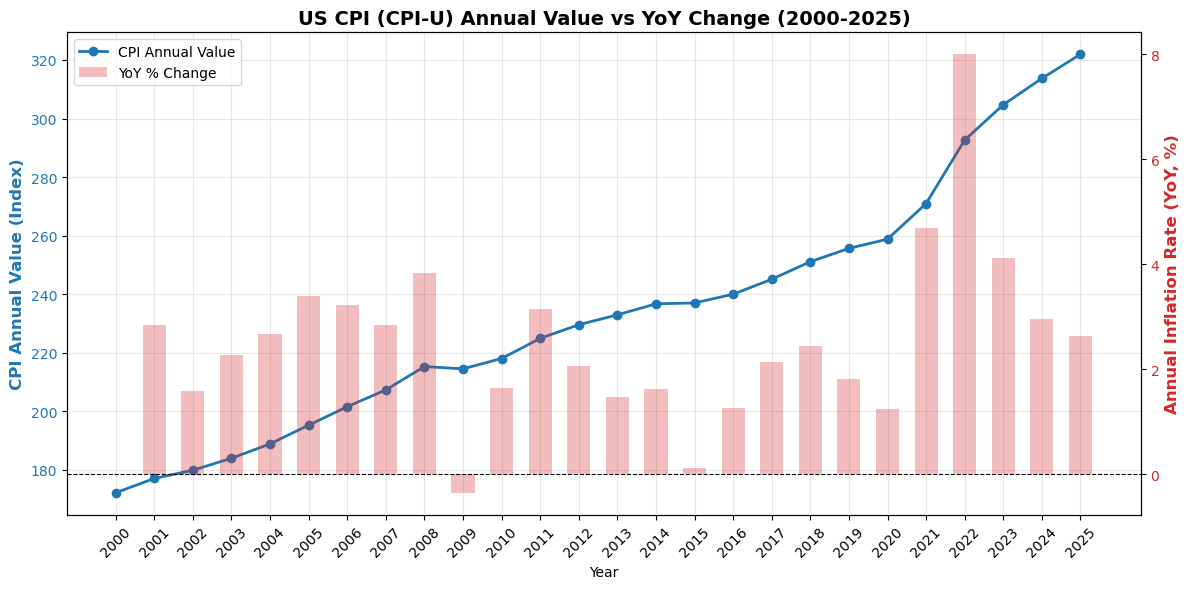

Saved plot to: /Users/Jeep/Documents/duke_mss/stat_698/Capstone_Citizensbank_climate-risk_insurance-exposure_monitoring/02_processed_data/cpi_trend_2000_2025.png


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# -----------------------
# CONFIG
# -----------------------
CPI_VALUE_FILE = "CPI_annual_value.xlsx"   # 你截图里的 annual value 文件
SKIP_ROWS = 11                             # 忽略前 11 行
START_YEAR = 2000
END_YEAR = 2025

def find_upwards(start: Path, target_dir_name: str, max_levels: int = 15) -> Path:
    cur = start.resolve()
    for _ in range(max_levels + 1):
        candidate = cur / target_dir_name
        if candidate.exists() and candidate.is_dir():
            return candidate
        if cur.parent == cur:
            break
        cur = cur.parent
    raise FileNotFoundError(f"Cannot find folder '{target_dir_name}' going up from {start.resolve()}")

def read_cpi_annual_value(path: Path, skiprows: int = 11) -> pd.DataFrame:
    df = pd.read_excel(path, skiprows=skiprows)
    df.columns = [str(c).strip() for c in df.columns]

    if "Year" not in df.columns or "Annual" not in df.columns:
        raise ValueError(f"Expected columns Year & Annual, got: {list(df.columns)}")

    df = df[["Year", "Annual"]].copy()
    df = df.dropna(subset=["Year", "Annual"])

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df["Annual"] = pd.to_numeric(df["Annual"], errors="coerce")
    df = df.dropna(subset=["Year", "Annual"]).copy()

    df["Year"] = df["Year"].astype(int)
    df = df.sort_values("Year").reset_index(drop=True)

    df = df.rename(columns={"Annual": "cpi_annual_value"})
    return df

def main():
    # 1) Find data dir and load CPI annual value
    cwd = Path.cwd()
    data_dir = find_upwards(cwd, "02_processed_data")
    cpi_path = data_dir / CPI_VALUE_FILE

    if not cpi_path.exists():
        raise FileNotFoundError(f"File not found: {cpi_path}\nExisting xlsx files: {[p.name for p in data_dir.glob('*.xlsx')]}")

    cpi = read_cpi_annual_value(cpi_path, skiprows=SKIP_ROWS)

    # 2) Filter years and compute YoY growth (%)
    cpi_view = cpi[cpi["Year"].between(START_YEAR, END_YEAR)].copy()
    cpi_view["pct_change"] = cpi_view["cpi_annual_value"].pct_change() * 100

    # 3) Plot
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # --- Line chart: CPI level (left axis) ---
    color1 = "tab:blue"
    ax1.set_xlabel("Year")
    ax1.set_ylabel("CPI Annual Value (Index)", color=color1, fontsize=12, fontweight="bold")
    ax1.plot(
        cpi_view["Year"],
        cpi_view["cpi_annual_value"],
        color=color1,
        marker="o",
        linewidth=2,
        label="CPI Annual Value",
    )
    ax1.tick_params(axis="y", labelcolor=color1)
    ax1.grid(True, alpha=0.3)

    # --- Bar chart: YoY growth (right axis) ---
    ax2 = ax1.twinx()
    color2 = "tab:red"
    ax2.set_ylabel("Annual Inflation Rate (YoY, %)", color=color2, fontsize=12, fontweight="bold")
    ax2.bar(
        cpi_view["Year"],
        cpi_view["pct_change"],
        color=color2,
        alpha=0.3,
        width=0.6,
        label="YoY % Change",
    )
    ax2.tick_params(axis="y", labelcolor=color2)

    # Horizontal line at 0%
    ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    # Title + x ticks
    plt.title(f"US CPI (CPI-U) Annual Value vs YoY Change ({START_YEAR}-{END_YEAR})",
              fontsize=14, fontweight="bold")
    ax1.set_xticks(range(START_YEAR, END_YEAR + 1))
    ax1.set_xticklabels(range(START_YEAR, END_YEAR + 1), rotation=45)

    plt.tight_layout()

    out_path = data_dir / f"cpi_trend_{START_YEAR}_{END_YEAR}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()

    print("Saved plot to:", out_path)

if __name__ == "__main__":
    main()


In [9]:
csv_path = "../../02_processed_data/FINAL_CLIMATE_FINANCIAL_DATA.csv"
df = pd.read_csv(csv_path, low_memory=False)
df

,Unnamed: 0,county_fips5,yr,hpi_change,index_nsa,state,flood_frequency,flood_property_damage,flood_duration_hours,heat_stress_index,...,deaths_hurricane,injuries_hurricane,damage_hurricane,real_gdp,unemployment_rate,prop_rate,county_fips,total_home_purchase,total_amt_purchase,total_population
0,14,1001,2000,2.50,141.23,ALABAMA,1.0,200000.0,3.50,0.546615,...,0.0,0.0,0.0,0,4.1,0.000,1001.0,831.0,72778000.0,44021.0
1,15,1001,2001,3.44,146.08,ALABAMA,2.0,37000.0,4.25,0.295779,...,0.0,0.0,0.0,1041239,4.1,0.000,1001.0,766.0,71592000.0,44889.0
2,16,1001,2002,2.67,149.98,ALABAMA,0.0,0.0,0.00,0.378973,...,0.0,0.0,0.0,1080135,4.8,0.000,1001.0,730.0,78607000.0,45909.0
3,17,1001,2003,1.79,152.66,ALABAMA,2.0,58000.0,6.00,0.277611,...,0.0,0.0,0.0,1111465,5.0,0.245,1001.0,835.0,93128000.0,46800.0
4,18,1001,2004,2.92,157.12,ALABAMA,1.0,8000.0,3.50,0.411246,...,0.0,0.0,0.0,1283522,4.7,0.245,1001.0,908.0,111256000.0,48366.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57236,103285,56045,2016,1.50,207.30,WYOMING,0.0,0.0,0.00,0.439590,...,0.0,0.0,0.0,284675,5.0,0.000,56045.0,25.0,3524000.0,7228.0
57237,103286,56045,2017,0.99,209.35,WYOMING,0.0,0.0,0.00,0.327758,...,0.0,0.0,0.0,285172,4.1,0.000,56045.0,70.0,10758000.0,6962.0
57238,103287,56045,2018,-1.00,207.26,WYOMING,1.0,0.0,40.08,0.144667,...,0.0,0.0,0.0,294224,3.5,0.000,56045.0,44.0,6840000.0,6895.0
57239,103288,56045,2019,8.55,224.99,WYOMING,4.0,35000.0,28.75,0.184251,...,0.0,0.0,0.0,303539,3.0,0.000,56045.0,51.0,10475000.0,6880.0
